# 중간 단계의 상태(State) 수동 업데이트

LangGraph는 **중간 단계의 상태를 수동으로 업데이트** 할 수 있는 방안을 제공하고 있습니다.

상태를 업데이트하면 **에이전트의 행동을 수정하여 경로를 제어** 할 수 있으며, 심지어 과거를 수정할 수도 있습니다. 

이 기능은 **에이전트의 실수를 수정** 하거나, **대체 경로를 탐색** 하거나, 특정 목표에 따라 **에이전트의 동작을 변경** 할 때 특히 유용합니다.

- 참고: 본 튜토리얼에서 사용하는 에이전트는 이전 튜토리얼과 동일한 그래프를 정의합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Modules")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Modules


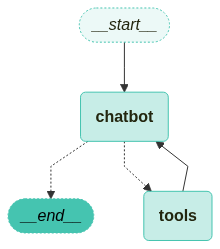

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_teddynote.tools.tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_teddynote.graphs import visualize_graph


########## 1. 상태 정의 ##########
# 상태 정의
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]


########## 2. 도구 정의 및 바인딩 ##########
# 도구 초기화
tool = TavilySearch(max_results=3)

# 도구 목록 정의
tools = [tool]

# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini")

# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
graph_builder = StateGraph(State)

# 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)


# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=tools)

# 도구 노드 추가
graph_builder.add_node("tools", tool_node)

# 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
graph_builder.add_edge("tools", "chatbot")

# START > chatbot
graph_builder.add_edge(START, "chatbot")

# chatbot > END
graph_builder.add_edge("chatbot", END)

########## 5. 그래프 컴파일 ##########
# 메모리 저장소 초기화
memory = MemorySaver()

# 그래프 빌더 컴파일
graph = graph_builder.compile(checkpointer=memory)

########## 6. 그래프 시각화 ##########
# 그래프 시각화
visualize_graph(graph)

In [4]:
from langchain_core.runnables import RunnableConfig

# 질문
question = "LangGraph 가 무엇인지 조사하여 알려주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# config 설정
config = RunnableConfig(
    configurable={"thread_id": "1"},  # 스레드 ID 설정
)

우선 채널목록을 출력하여 **interrupt_before** 와 **interrupt_after** 를 적용할 수 있는 목록을 출력합니다.

In [5]:
# 그래프 채널 목록 출력
list(graph.channels)

['messages',
 '__start__',
 '__pregel_tasks',
 'branch:to:chatbot',
 'branch:to:tools']

In [6]:
# 그래프 스트림 호출
events = graph.stream(
    input=input, config=config, interrupt_before=["tools"], stream_mode="values"
)

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_cPbq9kcObIUebyqKfm3NBWK1)
 Call ID: call_cPbq9kcObIUebyqKfm3NBWK1
  Args:
    query: LangGraph


현재 단계는 `ToolNode` 에 의해 중단되었습니다.

가장 최근 메시지를 확인하면 `ToolNode` 가 검색을 수행하기 전 `query` 를 포함하고 있음을 알 수 있습니다.

여기서는 `query` 가 단순하게 `LangGraph` 라는 단어만을 포함하고 있습니다. (기존의 질문은 `"LangGraph 가 무엇인지 조사하여 알려주세요!"` 였습니다.)

당연하게도, 웹 검색 결과가 우리가 원하는 결과와 다를 수 있습니다.

In [7]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 가장 최근 메시지 추출
last_message = snapshot.values["messages"][-1]

# 메시지 출력
last_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_cPbq9kcObIUebyqKfm3NBWK1)
 Call ID: call_cPbq9kcObIUebyqKfm3NBWK1
  Args:
    query: LangGraph


## 사람의 개입 (Human-in-the-loop)

- `TavilySearch` 도구에서 **검색 결과** 를 수정

우리는 종종 `ToolMessage` 의 결과가 마음에 들지 않는 경우가 있습니다.

특히, 웹 검색하여 얻은 답변은 얼마든지 잘못된 정보가 포함될 수 있고, 이는 곧 챗봇의 답변에도 영향을 미칠 수 있습니다.

만약, 사람이 중간에 개입하여 웹 검색 도구인 `Tavily Tool` 의 검색 결과인 `ToolMessage` 를 수정하여 LLM 에게 전달하고 싶다면 어떻게 해야 할까요?

![](./image/langgraph-01.png)

아래는 원래의 웹 검색 결과와는 조금 다른 수정한 가상의 웹 검색 결과를 만들어 보았습니다

In [8]:
modified_search_result = """[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요."""

print(modified_search_result)

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


다음으로는 수정한 검색 결과를 `ToolMessage` 에 주입합니다.

**중요**

- 여기서 메시지를 수정하려면 수정하고자 하는 Message 와 일치하는 `tool_call_id` 를 지정해야 합니다.

In [10]:
# 수정하고자 하는 `ToolMessage` 의 `tool_call_id` 추출
tool_call_id = last_message.tool_calls[0]["id"]
print(tool_call_id)

call_cPbq9kcObIUebyqKfm3NBWK1


In [11]:
from langchain_core.messages import AIMessage, ToolMessage

new_messages = [
    # LLM API의 도구 호출과 일치하는 ToolMessage 필요
    ToolMessage(
        content=modified_search_result,
        tool_call_id=tool_call_id,
    ),
    # LLM의 응답에 직접적으로 내용 추가
    # AIMessage(content=modified_search_result),
]

new_messages[-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.


### StateGraph의 `update_state` 메서드

`update_state` 메서드는 주어진 값으로 그래프의 상태를 업데이트합니다. 이 메서드는 마치 `as_node`에서 값이 온 것처럼 동작합니다.

**매개변수**

- `config` (RunnableConfig): 실행 구성
- `values` (Optional[Union[dict[str, Any], Any]]): 업데이트할 값들
- `as_node` (Optional[str]): 값의 출처로 간주할 노드 이름. 기본값은 None

**반환값**

- RunnableConfig

**주요 기능**

1. 체크포인터를 통해 이전 상태를 로드하고 새로운 상태를 저장합니다.
2. 서브그래프에 대한 상태 업데이트를 처리합니다.
3. `as_node`가 지정되지 않은 경우, 마지막으로 상태를 업데이트한 노드를 찾습니다.
4. 지정된 노드의 writer들을 실행하여 상태를 업데이트합니다.
5. 업데이트된 상태를 체크포인트에 저장합니다.

**주요 로직**

1. 체크포인터를 확인하고, 없으면 ValueError를 발생시킵니다.
2. 서브그래프에 대한 업데이트인 경우, 해당 서브그래프의 `update_state` 메서드를 호출합니다.
3. 이전 체크포인트를 로드하고, 필요한 경우 `as_node`를 결정합니다.
4. 지정된 노드의 writer들을 사용하여 상태를 업데이트합니다.
5. 업데이트된 상태를 새로운 체크포인트로 저장합니다.

**참고**

- 이 메서드는 그래프의 상태를 수동으로 업데이트할 때 사용됩니다.
- 체크포인터를 사용하여 상태의 버전 관리와 지속성을 보장합니다.
- `as_node`를 지정하지 않으면 자동으로 결정되지만, 모호한 경우 오류가 발생할 수 있습니다.
- 상태 업데이트 중 SharedValues에 쓰기 작업은 허용되지 않습니다.

In [12]:
graph.update_state(
    # 업데이트할 상태 지정
    config,
    # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
    {"messages": new_messages},
    as_node="tools",
)

print("(최근 1개의 메시지 출력)\n")
print(graph.get_state(config).values["messages"][-1])

(최근 1개의 메시지 출력)

content='[수정된 웹 검색 결과] \nLangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.\nLangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.\n\n자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과\n테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.' id='add32dc4-09a1-45ff-8b7d-0c7252f77349' tool_call_id='call_cPbq9kcObIUebyqKfm3NBWK1'


이제 그래프가 완성되었습니다. 

최종 응답 메시지를 제공했기 때문입니다! 

상태 업데이트는 그래프 단계를 시뮬레이션하므로, 해당하는 `traces`도 생성합니다.

`messages`를 사전 정의된 `add_messages` 함수로 `Annotated` 처리했습니다. (이는 그래프에 기존 목록을 직접 덮어쓰지 않고 항상 값을 추가합니다.)

동일한 논리가 여기에도 적용되어, `update_state`에 전달된 메시지가 동일한 방식으로 메시지가 추가하게 됩니다.

`update_state` 함수는 마치 그래프의 노드 중 하나인 것처럼 작동합니다! 기본적으로 업데이트 작업은 마지막으로 실행된 노드를 사용하지만, 아래에서 수동으로 지정할 수 있습니다. 업데이트를 추가하고 그래프에 "chatbot"에서 온 것처럼 처리하도록 지시해 봅시다.


In [13]:
snapshot = graph.get_state(config)
snapshot.next

('chatbot',)

In [14]:
# `None`는 현재 상태에 아무것도 추가하지 않음
events = graph.stream(None, config, stream_mode="values")

# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지의 예쁜 출력
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

LangGraph는 상태 기반의 다중 액터 애플리케이션을 구축할 수 있도록 지원하는 오픈 소스 라이브러리입니다. 이 라이브러리는 LLM(대규모 언어 모델)을 활용하며, 다음과 같은 기능을 제공합니다:

- 사이클 흐름
- 제어 가능성
- 지속성
- 클라우드 배포 기능

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 및 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785)을 참고하실 수 있습니다.


아래는 최종 답변의 상태도 수정하고자 할 경우 사용할 수 있는 코드입니다.

In [ ]:
# 이 함수가 작동할 노드 지정. 이 노드가 방금 실행된 것처럼 자동으로 처리 계속
# graph.update_state(
#     config,
#     {
#         "messages": [
#             AIMessage(content="마지막으로 최종 메시지를 추가하여 마무리 합니다.")
#         ]
#     },
#     as_node="chatbot",
# )

그럼, 그래프를 시각화하고 전체 출력을 확인해 보겠습니다.

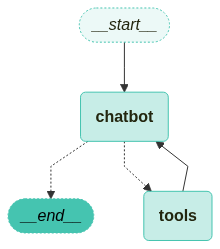

In [15]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph)

현재 상태를 이전과 같이 점검하여 체크포인트가 수동 업데이트를 반영하는지 확인합니다.

In [16]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 최근 세 개의 메시지 출력
for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

LangGraph 가 무엇인지 조사하여 알려주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_cPbq9kcObIUebyqKfm3NBWK1)
 Call ID: call_cPbq9kcObIUebyqKfm3NBWK1
  Args:
    query: LangGraph
================================= Tool Message =================================

[수정된 웹 검색 결과] 
LangGraph는 상태 기반의 다중 액터 애플리케이션을 LLM을 활용해 구축할 수 있도록 지원합니다.
LangGraph는 사이클 흐름, 제어 가능성, 지속성, 클라우드 배포 기능을 제공하는 오픈 소스 라이브러리입니다.

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 과
테디노트의 [랭체인 한국어 튜토리얼](https://wikidocs.net/233785) 을 참고하세요.
================================== Ai Message ==================================

LangGraph는 상태 기반의 다중 액터 애플리케이션을 구축할 수 있도록 지원하는 오픈 소스 라이브러리입니다. 이 라이브러리는 LLM(대규모 언어 모델)을 활용하며, 다음과 같은 기능을 제공합니다:

- 사이클 흐름
- 제어 가능성
- 지속성
- 클라우드 배포 기능

자세한 튜토리얼은 [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/) 

진행할 다음 노드가 있는지 확인합니다. `()` 가 비어 있는 것으로 확인할 수 있습니다. 즉, 모든 과정이 정상적으로 진행되었음을 알 수 있습니다.

In [17]:
# 다음 상태 출력
print(snapshot.next)

()


## Interrupt 후 메시지 상태 업데이트 - 이어서 진행

- `TavilySearch` 도구에서 **검색 쿼리** 를 수정

이번에는 다음 노드로 진행하기 전 interrupt 를 발생시켜 중단하고, 상태(State) 를 갱신한 뒤 이어서 진행하는 방법을 살펴보겠습니다.

먼저, 새로운 `thread_id` 를 생성합니다.

여기서는 랜덤한 해시값을 생성하는 `generate_random_hash` 함수를 사용합니다.

In [18]:
from langchain_teddynote.graphs import generate_random_hash

thread_id = generate_random_hash()
print(f"thread_id: {thread_id}")

question = "LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!"

# 초기 입력 상태를 정의
input = State(messages=[("user", question)])

# 새로운 config 생성
config = {"configurable": {"thread_id": thread_id}}

events = graph.stream(
    input=input,
    config=config,
    interrupt_before=["tools"],
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

thread_id: 227ed8
================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_zxyyQ6k8Kupvjntdto4gIQEG)
 Call ID: call_zxyyQ6k8Kupvjntdto4gIQEG
  Args:
    query: LangGraph


다음으로, 에이전트를 위한 도구 호출을 업데이트해 보겠습니다. 

먼저 `Message ID` 를 가져옵니다.

In [19]:
# config 를 복사
config_copy = config.copy()

In [20]:
from langchain_core.messages import AIMessage

# 스냅샷 상태 가져오기
snapshot = graph.get_state(config)

# messages 의 마지막 메시지 가져오기
existing_message = snapshot.values["messages"][-1]

# 메시지 ID 출력
print("Message ID", existing_message.id)

Message ID run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0


마지막 메시지는 `tavily_web_search` 도구 호출과 관련된 메시지 입니다.

주요 속성은 다음과 같습니다.

- `name`: 도구의 이름
- `args`: 검색 쿼리
- `id`: 도구 호출 ID
- `type`: 도구 호출 유형(tool_call)

In [21]:
# 첫 번째 도구 호출 출력
print(existing_message.tool_calls[0])

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph'}, 'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG', 'type': 'tool_call'}


위의 속성 값 중 `args` 의 `query` 를 업데이트 해 보겠습니다.

기존의 `existing_message` 를 복사하여 새로운 도구인 `new_tool_call` 을 생성합니다.

`copy()` 메서드를 사용하여 복사하였기 때문에 모든 속성 값이 복사됩니다.

그런 다음, `query` 매개변수에 원하는 **검색 쿼리** 를 입력합니다.

**중요**

- `id` 는 기존 메시지의 `id` 를 그대로 사용합니다. (`id` 가 달라지면 message 리듀서가 동작하여 메시지를 갱신하지 않고, 추가하게 됩니다.)

In [22]:
# tool_calls 를 복사하여 새로운 도구 호출 생성
new_tool_call = existing_message.tool_calls[0].copy()

# 쿼리 매개변수 업데이트(갱신)
new_tool_call["args"] = {"query": "LangGraph site:teddylee777.github.io"}
new_tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph site:teddylee777.github.io'},
 'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG',
 'type': 'tool_call'}

In [23]:
# AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

print(new_message.id)

# 수정한 메시지 출력
new_message.pretty_print()

run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_zxyyQ6k8Kupvjntdto4gIQEG)
 Call ID: call_zxyyQ6k8Kupvjntdto4gIQEG
  Args:
    query: LangGraph site:teddylee777.github.io


검색 쿼리가 갱신된 것을 확인할 수 있습니다.

In [24]:
# 업데이트된 도구 호출 출력
print(new_message.tool_calls[0])

# 메시지 ID 출력
print("\nMessage ID", new_message.id)

# 상태 업데이트
graph.update_state(config, {"messages": [new_message]})

{'name': 'tavily_web_search', 'args': {'query': 'LangGraph site:teddylee777.github.io'}, 'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG', 'type': 'tool_call'}

Message ID run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0


{'configurable': {'thread_id': '227ed8',
  'checkpoint_ns': '',
  'checkpoint_id': '1f091f6e-e317-6ccc-8002-c9f814551618'}}

업데이트된 마지막 message 의 `tool_calls` 를 확인합니다.

- `args` 의 `query` 가 수정된 것을 확인할 수 있습니다.

In [25]:
# 마지막 메시지의 도구 호출 가져오기
graph.get_state(config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph site:teddylee777.github.io'},
  'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG',
  'type': 'tool_call'}]

기존 검색어인 **"LangGraph"** 대신 변경된 검색 쿼리인 **"LangGraph site:teddylee777.github.io"** 로 검색되는 것을 확인할 수 있습니다.

기존 설정과 `None` 입력을 사용하여 그래프 이어서 스트리밍 합니다.

In [26]:
# 그래프 스트림에서 이벤트 수신
events = graph.stream(None, config, stream_mode="values")

# 각 이벤트에 대한 처리
for event in events:
    # 메시지가 있는 경우 마지막 메시지 출력
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_zxyyQ6k8Kupvjntdto4gIQEG)
 Call ID: call_zxyyQ6k8Kupvjntdto4gIQEG
  Args:
    query: LangGraph site:teddylee777.github.io
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.langchain.com/langgraph", "title": "LangGraph - LangChain", "content": "LangGraph sets the foundation for how we can build and scale AI workloads — from conversational agents, complex task automation, to custom LLM-backed", "score": 0.9859, "raw_content": "LangGraph\n\n===============\n\n![Image 1: Revisit consent button](https://uploads-ssl.webflow.com/65ff950538088944d66126b3/662ef3209b872e92e41212f6_cookieicon.png)\n\nWe value your privacy\n\nWe use cookies to analyze our traffic. By clicking \"Accept All\", you consent to our use of cookies.[Privacy Policy](https://www.langchain.com/privacy-policy)\n\nCustomize Reject A

In [27]:
# 이벤트 스트림 생성
events = graph.stream(
    {
        "messages": (
            "user",
            "내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 한국어로 답변해줘! 출처를 반드시 포함해줘!",
        )
    },
    config,
    stream_mode="values",
)

# 메시지 이벤트 처리
for event in events:
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================ Human Message =================================

내가 지금까지 배운 내용에 대해서 매우 친절하고 정성스럽게 한국어로 답변해줘! 출처를 반드시 포함해줘!
================================== Ai Message ==================================

물론입니다! LangGraph에 대한 내용을 요약하여 친절하게 설명드리겠습니다.

### LangGraph란?
LangGraph는 AI 에이전트를 구축하고 관리하는 데 사용되는 저수준의 오케스트레이션 프레임워크입니다. 개발자들은 LangGraph를 통해 신뢰할 수 있고 확장성이 뛰어난 언어 에이전트를 만들 수 있습니다. 이러한 에이전트는 장기적인 상태 유지가 가능하며, 다양한 작업을 적절하게 수행할 수 있도록 설계되었습니다.

### 주요 기능
1. **신뢰성과 제어 가능성**: LangGraph는 에이전트의 행동을 조정하기 위해 검토 및 승인 프로세스(인간-in-the-loop)를 통해 지속적이고 안정적인 성능을 보장합니다.
   
2. **저수준 및 확장 가능성**: 개발자는 고정된 추상화 없이 완전하게 설명 가능한 저수준 프리미티브를 사용하여 사용자 맞춤형 에이전트를 구축할 수 있습니다. 이를 통해 스케일 가능한 다중 에이전트 시스템을 디자인할 수 있습니다.

3. **1차 스트리밍 지원**: LangGraph는 토큰 단위 스트리밍 및 중간 단계 스트리밍을 지원하여, 에이전트의 추론과 행동이 실시간으로 어떻게 진행되는지 사용자에게 명확한 가시성을 제공합니다.

### 학습 자료
- **[LangGraph 공식 웹사이트](https://www.langchain.com/langgraph)**: LangGraph의 기능과 사용법에 대한 정보를 제공합니다.
- **[LangGraph GitHub 리포지토리](https://github.com/langchain-ai/lang

최종 상태에서 `messages` 의 마지막 메시지를 확인합니다. (이는 곧 최종 응답 메시지입니다.)

In [28]:
graph.get_state(config).values["messages"][-1].pretty_print()

================================== Ai Message ==================================

물론입니다! LangGraph에 대한 내용을 요약하여 친절하게 설명드리겠습니다.

### LangGraph란?
LangGraph는 AI 에이전트를 구축하고 관리하는 데 사용되는 저수준의 오케스트레이션 프레임워크입니다. 개발자들은 LangGraph를 통해 신뢰할 수 있고 확장성이 뛰어난 언어 에이전트를 만들 수 있습니다. 이러한 에이전트는 장기적인 상태 유지가 가능하며, 다양한 작업을 적절하게 수행할 수 있도록 설계되었습니다.

### 주요 기능
1. **신뢰성과 제어 가능성**: LangGraph는 에이전트의 행동을 조정하기 위해 검토 및 승인 프로세스(인간-in-the-loop)를 통해 지속적이고 안정적인 성능을 보장합니다.
   
2. **저수준 및 확장 가능성**: 개발자는 고정된 추상화 없이 완전하게 설명 가능한 저수준 프리미티브를 사용하여 사용자 맞춤형 에이전트를 구축할 수 있습니다. 이를 통해 스케일 가능한 다중 에이전트 시스템을 디자인할 수 있습니다.

3. **1차 스트리밍 지원**: LangGraph는 토큰 단위 스트리밍 및 중간 단계 스트리밍을 지원하여, 에이전트의 추론과 행동이 실시간으로 어떻게 진행되는지 사용자에게 명확한 가시성을 제공합니다.

### 학습 자료
- **[LangGraph 공식 웹사이트](https://www.langchain.com/langgraph)**: LangGraph의 기능과 사용법에 대한 정보를 제공합니다.
- **[LangGraph GitHub 리포지토리](https://github.com/langchain-ai/langgraph)**: 소스 코드와 업데이트 내역을 확인할 수 있습니다.
- **[LangGraph 튜토리얼 시리즈](https://langchain-ai.github.io/langgraph/tutorials/get-started/)**: 챗봇을 구축하는 

## 지난 스냅샷의 결과 수정 및 Replay

이번에는 지난 스냅샷의 결과를 수정하여 Replay 하는 방법을 살펴보겠습니다.

지난 스냅샷을 확인 후 특정 노드로 되돌아가, **상태(State) 를 수정한 뒤 해당 노드부터 다시 진행**합니다.

이를 Replay 라고 합니다.

먼저 지난 스냅샷의 상태를 가져옵니다.

In [29]:
to_replay_state = None

# 상태 기록 가져오기
for state in graph.get_state_history(config):

    messages = state.values["messages"]

    if len(messages) > 0:
        print(state.values["messages"][-1].id)
        # 메시지 수 및 다음 상태 출력
        print("메시지 수: ", len(state.values["messages"]), "다음 노드: ", state.next)
        print("-" * 80)
        # 특정 상태 선택 기준: 채팅 메시지 수
        if len(state.values["messages"]) == 2:
            # 특정 메시지 ID 선택
            to_replay_state = state

run--c22de31e-f082-48b0-abe9-c86454192adb-0
메시지 수:  6 다음 노드:  ()
--------------------------------------------------------------------------------
ec0aabd5-4eb8-4bb1-86d6-2d48afc83500
메시지 수:  5 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
run--91938380-7c4b-41dd-bd95-4820d34fee2c-0
메시지 수:  4 다음 노드:  ('__start__',)
--------------------------------------------------------------------------------
run--91938380-7c4b-41dd-bd95-4820d34fee2c-0
메시지 수:  4 다음 노드:  ()
--------------------------------------------------------------------------------
0db0584c-014e-45de-ac8d-8b1b5887e739
메시지 수:  3 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0
메시지 수:  2 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0
메시지 수:  2 다음 노드:  ('tools',)
-------------------------

선택한 메시지의 내용을 확인합니다.

In [30]:
from langchain_teddynote.messages import display_message_tree

# 선택한 메시지 가져오기
existing_message = to_replay_state.values["messages"][-1]

# 메시지 트리 출력
display_message_tree(existing_message)

    content: ""
    additional_kwargs:
        tool_calls:
            index [0]
                id: "call_zxyyQ6k8Kupvjntdto4gIQEG"
                function: {"arguments": "{"query":"LangGraph"}", "name": "tavily_web_search"}
                type: "function"
        refusal: None
    response_metadata:
        token_usage:
            completion_tokens: 18
            prompt_tokens: 110
            total_tokens: 128
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 0}
        model_name: "gpt-4o-mini-2024-07-18"
        system_fingerprint: "fp_560af6e559"
        id: "chatcmpl-CFwF2L3ltY3wRKBrFgW4GBZpoli2w"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "run--8acfb4b5-e730-4bf6-bb3d-3fdc40892a0f-0"
    example: False
    tool_calls:
    

검색 쿼리를 업데이트 후 반영이 됐는지 확인합니다.

In [31]:
tool_call = existing_message.tool_calls[0].copy()
tool_call["args"] = {"query": "LangGraph human-in-the-loop workflow site:reddit.com"}
tool_call

{'name': 'tavily_web_search',
 'args': {'query': 'LangGraph human-in-the-loop workflow site:reddit.com'},
 'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG',
 'type': 'tool_call'}

업데이트된 AIMessage 를 생성합니다.

In [32]:
# AIMessage 생성
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[tool_call],
    # 중요! ID는 메시지를 상태에 추가하는 대신 교체하는 방법
    id=existing_message.id,
)

# 수정한 메시지 출력
new_message.tool_calls[0]["args"]

{'query': 'LangGraph human-in-the-loop workflow site:reddit.com'}

아래는 업데이트가 되기 전의 메시지입니다.

In [33]:
# 업데이트 전 메시지 확인
graph.get_state(to_replay_state.config).values["messages"][-1].tool_calls

[{'name': 'tavily_web_search',
  'args': {'query': 'LangGraph'},
  'id': 'call_zxyyQ6k8Kupvjntdto4gIQEG',
  'type': 'tool_call'}]

`graph` 에 `update_state` 메서드를 사용하여 상태를 업데이트 합니다.

업데이트된 상태를 `updated_state` 에 저장합니다.

In [34]:
# 상태 업데이트
updated_state = graph.update_state(
    to_replay_state.config,
    {"messages": [new_message]},
)
updated_state

{'configurable': {'thread_id': '227ed8',
  'checkpoint_ns': '',
  'checkpoint_id': '1f091f77-aaef-6782-8002-eebd89a192fe'}}

이제 업데이트된 상태를 스트리밍 합니다. 여기서 입력은 `None` 으로 주어 Replay 합니다.

In [35]:
# config 에는 updated_state 를 전달합니다. 이는 임의로 갱신한 상태를 전달하는 것입니다.
for event in graph.stream(None, updated_state, stream_mode="values"):
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지 출력
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_zxyyQ6k8Kupvjntdto4gIQEG)
 Call ID: call_zxyyQ6k8Kupvjntdto4gIQEG
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/", "title": "LangGraph's human-in-the-loop - Overview", "content": "To review, edit, and approve tool calls in an agent or workflow, use LangGraph's human-in-the-loop features to enable human intervention at any point in a workflow. *   **Persistent execution state**: Interrupts use LangGraph's persistence layer, which saves the graph state, to indefinitely pause graph execution until you resume. This is possible because LangGraph checkpoints the graph state after each step, which allows the system to persist execution context and later resume the workf

최종 결과를 출력합니다.

이때 사용하는 `config` 는 최종 상태를 가져오는 것이 아니라, 최종 상태를 가져오기 위한 초기 `config` 입니다.

In [36]:
# 최종 결과 출력
for msg in graph.get_state(config).values["messages"]:
    msg.pretty_print()

================================ Human Message =================================

LangGraph 에 대해서 배워보고 싶습니다. 유용한 자료를 추천해 주세요!
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_zxyyQ6k8Kupvjntdto4gIQEG)
 Call ID: call_zxyyQ6k8Kupvjntdto4gIQEG
  Args:
    query: LangGraph human-in-the-loop workflow site:reddit.com
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/", "title": "LangGraph's human-in-the-loop - Overview", "content": "To review, edit, and approve tool calls in an agent or workflow, use LangGraph's human-in-the-loop features to enable human intervention at any point in a workflow. *   **Persistent execution state**: Interrupts use LangGraph's persistence layer, which saves the graph state, to indefinitely pause graph execution until you resume. This is possible because LangGrap